<a href="https://colab.research.google.com/github/BhaveshKhaple/advanced-ai-medical-intelligence-platform/blob/main/train/train_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫁 Medical AI Platform — Model Training
**EfficientNet-B0 fine-tuned on Chest X-Ray (Pneumonia) dataset**

Runtime: GPU (T4) · Expected time: ~20 minutes · **No Kaggle account needed**

Dataset downloads automatically from HuggingFace (free, public).
After training, download `model.pth` and place it in the `weights/` folder.

In [18]:
# Cell 1: Download and extract dataset
import os
import shutil
import subprocess

# Ensure huggingface_hub is installed
!pip install huggingface_hub -q
from huggingface_hub import snapshot_download

DATA_DIR = '/content/data/chest_xray'
# Clean up previous failed attempts to ensure a fresh start
if os.path.exists('/content/data'): shutil.rmtree('/content/data')
os.makedirs(DATA_DIR, exist_ok=True)

print('Downloading dataset files...')
temp_download_path = snapshot_download(
    repo_id="keremberke/chest-xray-classification",
    repo_type="dataset",
    cache_dir="/content/hf_cache"
)

source_data_path = os.path.join(temp_download_path, 'data')

print(f"Extracting files to {DATA_DIR}...")
for item in os.listdir(source_data_path):
    if item.endswith('.zip'):
        zip_path = os.path.join(source_data_path, item)
        folder_name = item.replace('.zip', '')

        # Standardize 'valid' to 'val'
        target_name = 'val' if folder_name == 'valid' else folder_name
        target_path = os.path.join(DATA_DIR, target_name)

        print(f"  Processing {item} -> {target_name}...")
        os.makedirs(target_path, exist_ok=True)
        # Unzip directly into the target folder
        subprocess.run(['unzip', '-o', '-q', zip_path, '-d', target_path])

print('\nDownload and extraction complete!')

# Verification of directories
found = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
print(f"Verified directories in {DATA_DIR}: {found}")
for d in found:
    subdirs = os.listdir(os.path.join(DATA_DIR, d))
    print(f"  Contents of {d}: {subdirs[:5]}...")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Extracting files to /content/data/chest_xray...
  Processing train.zip -> train...
  Processing valid.zip -> val...
  Processing test.zip -> test...
  Processing valid-mini.zip -> valid-mini...

Download and extraction complete!
Verified directories in /content/data/chest_xray: ['train', 'val', 'valid-mini', 'test']
  Contents of train: ['NORMAL', 'PNEUMONIA']...
  Contents of val: ['NORMAL', 'PNEUMONIA']...
  Contents of valid-mini: ['NORMAL', 'PNEUMONIA']...
  Contents of test: ['NORMAL', 'PNEUMONIA']...


In [19]:
# Cell 3: Imports and config
import torch
import torch.nn as nn
from torchvision import transforms, models, datasets
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4

Using device: cuda
GPU: Tesla T4


In [20]:
# Cell 4: Data loaders
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transform)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'),   transform=val_transform)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'),  transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Classes: {train_ds.classes}')  # Should be ['NORMAL', 'PNEUMONIA']

Train: 4077 | Val: 1165 | Test: 582
Classes: ['NORMAL', 'PNEUMONIA']


In [21]:
# Cell 5: Build model
model = models.efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(device)

# Handle class imbalance (more PNEUMONIA than NORMAL samples)
class_counts = np.bincount(train_ds.targets)
class_weights = 1.0 / class_counts
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model: EfficientNet-B0 | Parameters: {total_params:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 73.3MB/s]


Model: EfficientNet-B0 | Parameters: 4,010,110


In [22]:
# Cell 6: Training loop
def evaluate(loader, model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total * 100


best_val_acc = 0
history = {'train_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    val_acc = evaluate(val_loader, model)
    avg_loss = running_loss / len(train_loader)
    history['train_loss'].append(avg_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2f}%')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'model.pth')
        print(f'  ✓ Best model saved (val_acc={val_acc:.2f}%)')

    scheduler.step()

print(f'\nTraining complete. Best Val Accuracy: {best_val_acc:.2f}%')

Epoch 1/10 | Loss: 0.2420 | Val Acc: 95.54%
  ✓ Best model saved (val_acc=95.54%)
Epoch 2/10 | Loss: 0.1300 | Val Acc: 96.65%
  ✓ Best model saved (val_acc=96.65%)
Epoch 3/10 | Loss: 0.1001 | Val Acc: 95.71%
Epoch 4/10 | Loss: 0.0791 | Val Acc: 97.77%
  ✓ Best model saved (val_acc=97.77%)
Epoch 5/10 | Loss: 0.0649 | Val Acc: 97.17%
Epoch 6/10 | Loss: 0.0580 | Val Acc: 97.34%
Epoch 7/10 | Loss: 0.0495 | Val Acc: 97.68%
Epoch 8/10 | Loss: 0.0522 | Val Acc: 97.17%
Epoch 9/10 | Loss: 0.0533 | Val Acc: 97.42%
Epoch 10/10 | Loss: 0.0439 | Val Acc: 97.60%

Training complete. Best Val Accuracy: 97.77%


Test Accuracy: 97.08%


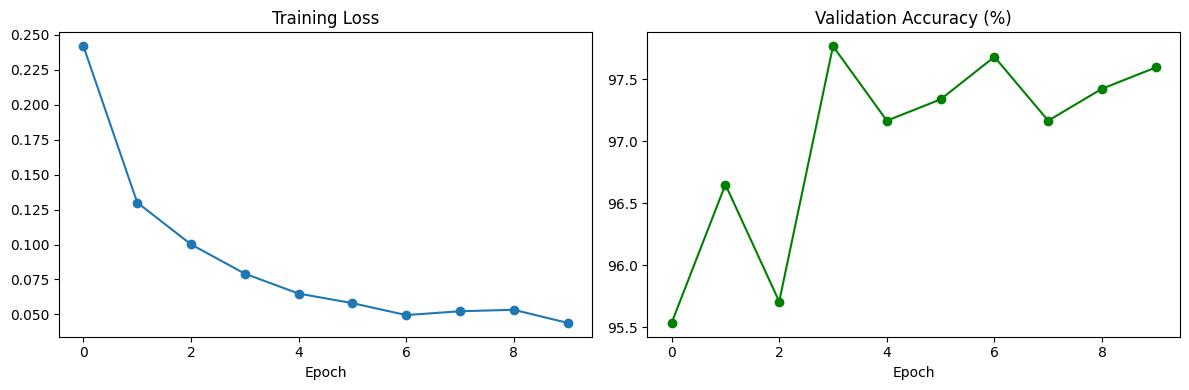

In [23]:
# Cell 7: Test evaluation + training curve
model.load_state_dict(torch.load('model.pth'))
test_acc = evaluate(test_loader, model)
print(f'Test Accuracy: {test_acc:.2f}%')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], marker='o')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax2.plot(history['val_acc'], marker='o', color='green')
ax2.set_title('Validation Accuracy (%)')
ax2.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('training_curve.png', dpi=150)
plt.show()

In [24]:
# Cell 8: Download to your machine
from google.colab import files
files.download('model.pth')
files.download('training_curve.png')
print('Done! Place model.pth in the weights/ folder of the project.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Place model.pth in the weights/ folder of the project.
